# SERGIO Simulation to AnnData + PHATE

Goals:
- Run SERGIO steady-state simulation
- Add realistic technical noise
- Convert to `AnnData` in a preprocess-like structure
- Add `time_bin` for downstream trajectory workflows
- Visualize PHATE and save a `.h5ad` file

## 1. Imports

In [11]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import phate
import matplotlib.pyplot as plt

np.int = int
np.float = float

from omics_toolbox.sergio import sergio

## 2. SERGIO dataset configuration

In [12]:
# === PHATE parameters for bifurcation-style separation ===
phate_knn = 5
phate_decay = 40
phate_t = "auto"

# === Neighbor graph for pseudotime ===
n_neighbors_dpt = 15

# === Pseudotime root and binning ===
root_strategy = "left"  # top, bottom, left, right, or manual
root_index = None  # set integer index when root_strategy="manual"
n_pseudotime_bins = 8
binning = "quantile"  # quantile or uniform

# === SERGIO simulation noise ===
sergio_noise = 0.005
sergio_sampling_state = 15
use_technical_noise = True  # use clean SERGIO state for clearer branch structure

# === Dataset size ===
use_more_genes = False  # Set True to use 200 genes instead of 100

### Tunable Parameters for Clear Trajectory Separation

**Quick tuning guide for clearer branch separation:**

- **For sharper, more separated branches in PHATE:**
  - ↑ `phate_knn` (10-20): smoother manifold
  - ↓ `phate_decay` (10-20): emphasize local structure
  - Set `phate_t` to 50-100: more diffusion → better global structure

- **For less blurry pseudotime bins:**
  - ↓ `n_neighbors_dpt` (10-20): less smoothing, sharper transitions

- **For cleaner trajectory signal:**
  - ↓ `sergio_noise` (0.01-0.05): less noise
  - ↑ `sergio_sampling_state` (20-30): more stable steady state
  - Set `use_more_genes = True`: 200 genes capture more variation

**Recommended starting point for clear separation:**
```python
phate_knn = 15
phate_decay = 10
phate_t = 80
n_neighbors_dpt = 12
sergio_noise = 0.03
sergio_sampling_state = 25
```

Mention the datasets here more clearly

In [ ]:
dataset = {
    "DS9": {
        "number_genes": 100,
        "number_bins": 3,
        "number_sc": 300,
        "bifurcation_matrix": "../data/raw/sergio_data/DS9/bMat_cID9.tab",
        "GRN": "../data/raw/sergio_data/DS9/Interaction_cID_9.txt",
        "master_regulator_prod_rate": "../data/raw/sergio_data/DS9/Regs_cID_9.txt",
        "save_location": "../data/raw/sergio_data/DS9/SERGIO_sim_DS9.npy"
    },
    "DS10": {
        "number_genes": 100,
        "number_bins": 4,
        "number_sc": 300,
        "bifurcation_matrix": "../data/raw/sergio_data/DS10/bMat_cID10.tab",
        "GRN": "../data/raw/sergio_data/DS10/Interaction_cID_10.txt",
        "master_regulator_prod_rate": "../data/raw/sergio_data/DS10/Regs_cID_10.txt",
        "save_location": "../data/raw/sergio_data/DS10/SERGIO_sim_DS10.npy"
    },
    "DS12": {
        "number_genes": 100,
        "number_bins": 7,
        "number_sc": 300,
        "bifurcation_matrix": "../data/raw/sergio_data/DS12/bMat_cID12.tab",
        "GRN": "../data/raw/sergio_data/DS12/Interaction_cID_12.txt",
        "master_regulator_prod_rate": "../data/raw/sergio_data/DS12/Regs_cID_12.txt",
        "save_location": "../data/raw/sergio_data/DS12/SERGIO_sim_DS12.npy"
    }
}

# For a clean bifurcation benchmark-like shape, start with DS9
sim_id = "DS9"  # choose from: DS9, DS10, DS12

# Apply gene count override if requested
if use_more_genes:
    dataset[sim_id]["number_genes"] = 200
    
dataset[sim_id]

{'number_genes': 100,
 'number_bins': 3,
 'number_sc': 300,
 'bifurcation_matrix': '../data/sergio_data/DS9/bMat_cID9.tab',
 'GRN': '../data/sergio_data/DS9/Interaction_cID_9.txt',
 'master_regulator_prod_rate': '../data/sergio_data/DS9/Regs_cID_9.txt',
 'save_location': '../data/sergio_data/DS9/SERGIO_sim_DS9.npy'}

## 3. Run steady-state SERGIO simulation

In [14]:
sim = sergio(
    number_genes=dataset[sim_id]["number_genes"],
    number_bins=dataset[sim_id]["number_bins"],
    number_sc=dataset[sim_id]["number_sc"],
    noise_params=sergio_noise,
    decays=0.8,
    sampling_state=sergio_sampling_state,
    noise_type='dpd'
)

sim.build_graph(
    dataset[sim_id]["GRN"],
    input_file_regs=dataset[sim_id]["master_regulator_prod_rate"],
    shared_coop_state=2
)

sim.simulate()
expr = sim.getExpressions()
expr_clean = np.concatenate(expr, axis=1)

print(f"Clean expression matrix shape (genes x cells): {expr_clean.shape}")

TypeError: 'module' object is not callable

## 4. Add technical noise and generate count matrix

In [379]:
if use_technical_noise:
    # Add outlier genes
    expr_o = sim.outlier_effect(expr, outlier_prob=0.01, mean=0.8, scale=1)

    # Add library size effect
    lib_factor, expr_o_l = sim.lib_size_effect(expr_o, mean=4.6, scale=0.4)

    # Add dropouts
    binary_ind = sim.dropout_indicator(expr_o_l, shape=6.5, percentile=82)
    expr_o_l_d = np.multiply(binary_ind, expr_o_l)

    # Convert to UMI counts
    count_matrix = sim.convert_to_UMIcounts(expr_o_l_d)
    count_matrix = np.concatenate(count_matrix, axis=1)
    print("Using technical-noise count matrix")
else:
    # Use clean SERGIO expression directly
    count_matrix = expr_clean.copy()
    print("Using clean SERGIO expression (no added technical noise)")

# Guardrail: if cells are nearly identical, add tiny jitter so PHATE does not collapse
unique_cells = np.unique(count_matrix.T, axis=0).shape[0]
if unique_cells <= dataset[sim_id]["number_bins"] + 1:
    rng = np.random.default_rng(0)
    count_matrix = count_matrix + rng.normal(loc=0.0, scale=1e-3, size=count_matrix.shape)
    count_matrix = np.clip(count_matrix, a_min=0, a_max=None)
    unique_cells = np.unique(count_matrix.T, axis=0).shape[0]
    print("Applied tiny jitter to break exact duplicates between cells")

print(f"Expression matrix used for AnnData (genes x cells): {count_matrix.shape}")
print(f"Unique cell profiles before PHATE: {unique_cells}")

Using technical-noise count matrix
Expression matrix used for AnnData (genes x cells): (100, 900)
Unique cell profiles before PHATE: 893


## 5. Convert to AnnData and keep simulation time labels

In [380]:
# SERGIO output is genes x cells; AnnData expects cells x genes
X_cells_by_genes = count_matrix.T
adata = sc.AnnData(X=X_cells_by_genes)

adata.var_names = [f"G{i}" for i in range(adata.n_vars)]
adata.obs_names = [f"cell_{i}" for i in range(adata.n_obs)]

# Keep simulation bins as reference labels
cells_per_bin = dataset[sim_id]["number_sc"]
number_bins = dataset[sim_id]["number_bins"]
expected_n_obs = cells_per_bin * number_bins

if adata.n_obs != expected_n_obs:
    raise ValueError(
        f"Expected {expected_n_obs} cells ({number_bins} bins x {cells_per_bin} cells), got {adata.n_obs}."
    )

adata.obs["sim_time_bin"] = np.repeat(np.arange(number_bins, dtype=float), cells_per_bin)
adata.obs["sim_timepoint"] = adata.obs["sim_time_bin"].map(lambda x: f"Bin {int(x)}")

adata

AnnData object with n_obs × n_vars = 900 × 100
    obs: 'sim_time_bin', 'sim_timepoint'

## 6. PHATE embedding + pseudotime (8 bins)

Calculating PHATE...
  Running PHATE on 900 observations and 30 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.02 seconds.
    Calculating affinities...
  Calculated graph and diffusion operator in 0.03 seconds.
  Calculating optimal t...


/Users/siddharthviswanath/miniconda3/envs/omics_toolbox/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/Users/siddharthviswanath/miniconda3/envs/omics_toolbox/lib/python3.10/site-packages/graphtools/graphs.py:290: RuntimeWarning: Detected zero distance between 27 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
/Users/siddharthviswanath/miniconda3/envs/omics_toolbox/lib/python3.10/site-packages/graphtools/graphs.py:454: RuntimeWarning: overflow encountered in power
  K.data = np.exp(-1 * np.power(K.data, self.decay))


    Automatically selected t = 20
  Calculated optimal t in 0.22 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.08 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 0.28 seconds.
Calculated PHATE in 0.62 seconds.


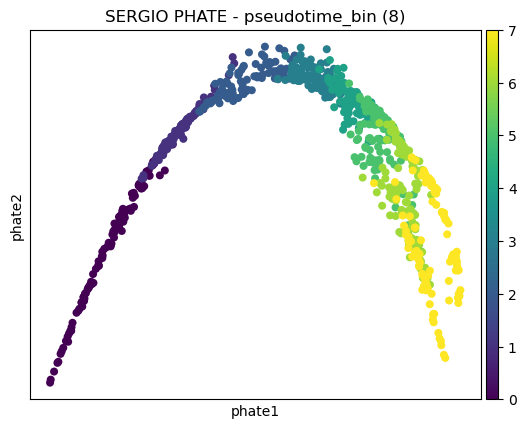

In [381]:
# Preprocess and compute PCA directly on adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata, n_comps=min(30, adata.n_vars - 1))

# Compute PHATE on PCA embedding and store
phate_operator = phate.PHATE(
    n_jobs=-2, 
    n_components=2,
    knn=phate_knn,
    decay=phate_decay,
    t=phate_t,
    random_state=0
)
adata.obsm["X_phate"] = phate_operator.fit_transform(adata.obsm["X_pca"])

# Compute pseudotime using diffusion pseudotime (DPT)
sc.pp.neighbors(adata, n_neighbors=n_neighbors_dpt, n_pcs=min(30, adata.n_vars - 1))
sc.tl.diffmap(adata)

# Choose root to orient trajectory
if root_strategy == "manual" and root_index is not None:
    root_idx = int(root_index)
elif root_strategy == "top":
    root_idx = int(np.argmax(adata.obsm["X_phate"][:, 1]))
elif root_strategy == "bottom":
    root_idx = int(np.argmin(adata.obsm["X_phate"][:, 1]))
elif root_strategy == "left":
    root_idx = int(np.argmin(adata.obsm["X_phate"][:, 0]))
elif root_strategy == "right":
    root_idx = int(np.argmax(adata.obsm["X_phate"][:, 0]))
else:
    root_idx = int(np.argmin(adata.obsm["X_phate"][:, 0]))

adata.uns["iroot"] = root_idx
sc.tl.dpt(adata)

# Store pseudotime bins
if binning == "uniform":
    adata.obs["pseudotime_bin"] = pd.cut(
        adata.obs["dpt_pseudotime"],
        bins=n_pseudotime_bins,
        labels=False,
        include_lowest=True
    ).astype(int)
else:
    adata.obs["pseudotime_bin"] = pd.qcut(
        adata.obs["dpt_pseudotime"],
        q=n_pseudotime_bins,
        labels=False,
        duplicates="drop"
    ).astype(int)

sc.pl.embedding(
    adata,
    basis='phate',
    color='pseudotime_bin',
    cmap='viridis',
    title='SERGIO PHATE - pseudotime_bin (8)'
)

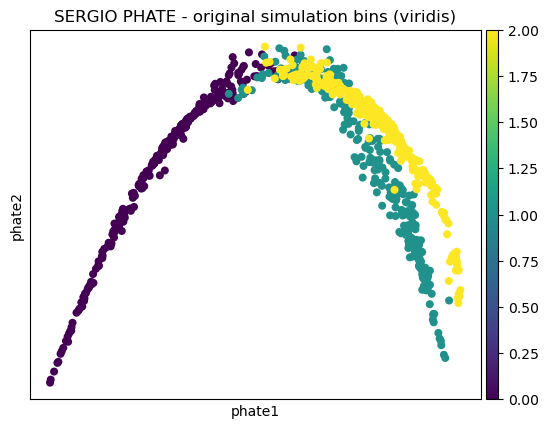

In [382]:
# PHATE visualization using original SERGIO bins only (no pseudotime)
sc.pl.embedding(
    adata,
    basis='phate',
    color='sim_time_bin',
    cmap='viridis',
    title='SERGIO PHATE - original simulation bins (viridis)'
)

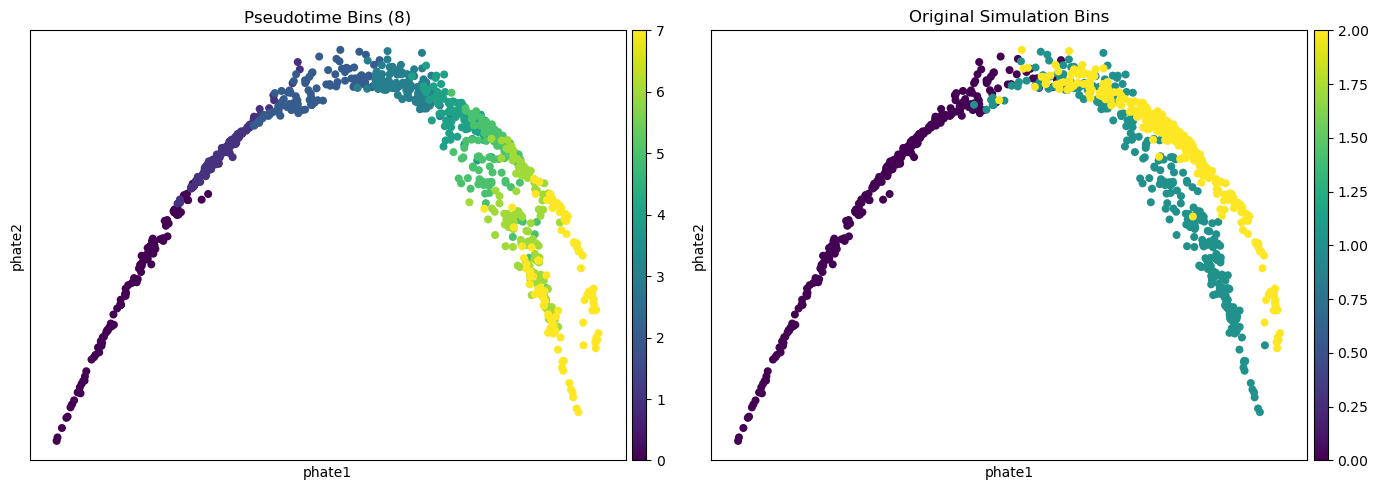


Parameters used:
  PHATE: knn=5, decay=40, t=auto
  DPT neighbors: 15
  SERGIO noise: 0.005
  Sampling state: 15


In [383]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pseudotime bins
sc.pl.embedding(
    adata,
    basis='phate',
    color='pseudotime_bin',
    cmap='viridis',
    ax=axes[0],
    title='Pseudotime Bins (8)',
    show=False
)

# Simulation bins (reference)
sc.pl.embedding(
    adata,
    basis='phate',
    color='sim_time_bin',
    cmap='viridis',
    ax=axes[1],
    title='Original Simulation Bins',
    show=False
)

plt.tight_layout()
plt.show()

print(f"\nParameters used:")
print(f"  PHATE: knn={phate_knn}, decay={phate_decay}, t={phate_t}")
print(f"  DPT neighbors: {n_neighbors_dpt}")
print(f"  SERGIO noise: {sergio_noise}")
print(f"  Sampling state: {sergio_sampling_state}")

In [384]:
pseudotime_bin_counts = (
    adata.obs['pseudotime_bin']
    .value_counts()
    .sort_index()
    .rename_axis('pseudotime_bin')
    .reset_index(name='n_cells')
)

print('Cells per pseudotime_bin:')
display(pseudotime_bin_counts)

print('Simulation bins kept for reference:')
display(
    adata.obs['sim_time_bin']
    .value_counts()
    .sort_index()
    .rename_axis('sim_time_bin')
    .reset_index(name='n_cells')
)

Cells per pseudotime_bin:


,pseudotime_bin,n_cells
0,0,113
1,1,112
2,2,113
3,3,112
4,4,112
5,5,113
6,6,112
7,7,113


Simulation bins kept for reference:


,sim_time_bin,n_cells
0,0.0,300
1,1.0,300
2,2.0,300


## 7. Save simulation outputs

In [ ]:
# Save numpy simulation bundle
sim_data = {
    "steady_state_expr": expr,
    "steady_state_expr_clean": expr_clean,
    "steady_state_expr_noisy": count_matrix
}
np.save(dataset[sim_id]["save_location"], sim_data)

h5ad_path = os.path.join(os.path.dirname(dataset[sim_id]["save_location"]), f"SERGIO_sim_{sim_id}.h5ad")
adata.write_h5ad(h5ad_path)

print(f"Saved simulation bundle: {dataset[sim_id]['save_location']}")
print(f"Saved AnnData file: {h5ad_path}")
print(adata.obs[['sim_time_bin', 'sim_timepoint', 'pseudotime', 'pseudotime_bin']].head())

Saved simulation bundle: data/DS9/SERGIO_sim_DS9.npy
Saved AnnData file: data/DS9/SERGIO_sim_DS9.h5ad
        time_bin timepoint
cell_0       0.0     Bin 0
cell_1       0.0     Bin 0
cell_2       0.0     Bin 0
cell_3       0.0     Bin 0
cell_4       0.0     Bin 0
